### **Custom ResNet Model**

The **Custom ResNet Model** is a deep convolutional neural network built on the principles of **Residual Learning**. It is designed to address the vanishing gradient problem in very deep networks by introducing **skip connections (residual blocks)** that allow gradients to flow directly through identity mappings.

This custom implementation is inspired by the original ResNet architecture but tailored with flexible hyperparameters to suit specific datasets and computational constraints. It incorporates:

- **Custom Residual Blocks** with Batch Normalization and ReLU activation.
- **Configurable Depth** to adapt to dataset complexity.
- **Data Augmentation & Preprocessing** for improved generalization.
- **Regularization** techniques like Dropout to prevent overfitting.
- **Adaptive Learning Rate Scheduling** for optimized training.

The model is trained end-to-end using **Adam/SGD optimizers** and evaluated on accuracy, loss curves, and confusion matrices.
It is particularly suited for **image classification** tasks across domains such as medical imaging, object recognition, and scene classification.

---


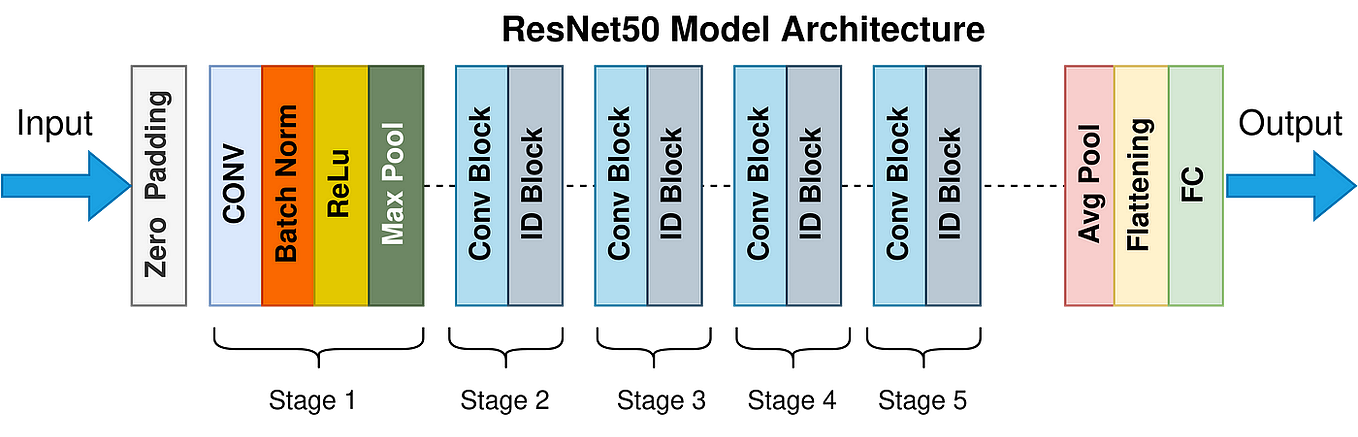


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Input,
    Dropout,
    Conv2D,
    BatchNormalization,
    Activation,
    Add,
    MaxPool2D,
    GlobalAveragePooling2D,
)
from tensorflow.keras.datasets import mnist as mnist
from tensorflow.keras.utils import plot_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


y_test = y_test.flatten()

In [ ]:
class IdentityBlock(Model):
    def __init__(self, filters, kernel_size):
        super(IdentityBlock, self).__init__(name="")
        self.conv1 = Conv2D(filters, kernel_size, padding="same")
        self.bn1 = BatchNormalization()
        self.conv2 = Conv2D(filters, kernel_size, padding="same")
        self.bn2 = BatchNormalization()
        self.act1 = Activation("relu")
        self.add = Add()

    def call(self, input_tensor):
        x = self.conv1(input_tensor)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.add([x, input_tensor])
        x = self.act1(x)

        return x

In [ ]:
class ResNetSmall(tf.keras.Model):
    def __init__(self, num_classes):
        super().__init__()

        self.aug = tf.keras.Sequential(
            [
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.1),
            ]
        )

        self.conv1 = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")
        self.id_block1 = IdentityBlock(64, 3)
        self.id_block2 = IdentityBlock(64, 3)

        self.conv2 = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.id_block3 = IdentityBlock(128, 3)
        self.id_block4 = IdentityBlock(128, 3)

        self.pool = tf.keras.layers.GlobalAveragePooling2D()
        self.dropout = tf.keras.layers.Dropout(0.5)
        self.fc = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, x, training=False):
        x = self.aug(x, training=training)
        x = self.conv1(x)
        x = self.id_block1(x, training=training)
        x = self.id_block2(x, training=training)
        x = self.conv2(x)
        x = self.id_block3(x, training=training)
        x = self.id_block4(x, training=training)
        x = self.pool(x)
        x = self.dropout(x, training=training)
        return self.fc(x)

In [ ]:
model = ResNetSmall(num_classes=10)
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train, epochs=75, batch_size=32, validation_data=(x_test, y_test)
)


plot_model(model, to_file="custom_rsenet.png", show_shapes=True, show_layer_names=True)

loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

model.save("custom_resnet_model.h5")

sample = np.expand_dims(x_test[0], axis=0)  #
prediction = model.predict(sample)
print("Predicted label:", tf.argmax(prediction[0]).numpy())
print("Actual label:", y_test[0])

Epoch 1/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 40ms/step - accuracy: 0.2647 - loss: 2.0076 - val_accuracy: 0.4410 - val_loss: 1.5310
Epoch 2/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.4539 - loss: 1.4869 - val_accuracy: 0.4539 - val_loss: 1.6090
Epoch 3/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5319 - loss: 1.2974 - val_accuracy: 0.4842 - val_loss: 1.4614
Epoch 4/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5678 - loss: 1.2176 - val_accuracy: 0.5821 - val_loss: 1.1833
Epoch 5/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5973 - loss: 1.1352 - val_accuracy: 0.5344 - val_loss: 1.3317
Epoch 6/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6218 - loss: 1.0793 - val_accuracy: 0.6203 - val_loss: 1.0988
Epoch 7/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6442 - loss: 1.0214 - val_accuracy: 0.6402 - val_loss: 1.0981
Epoch 8/75
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6552 -

ValueError: Unable to synchronously create group (name parameter cannot be an empty string)

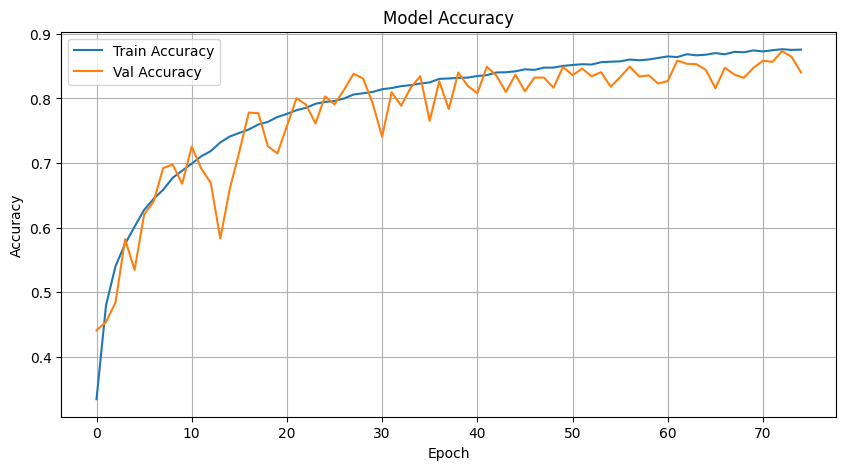

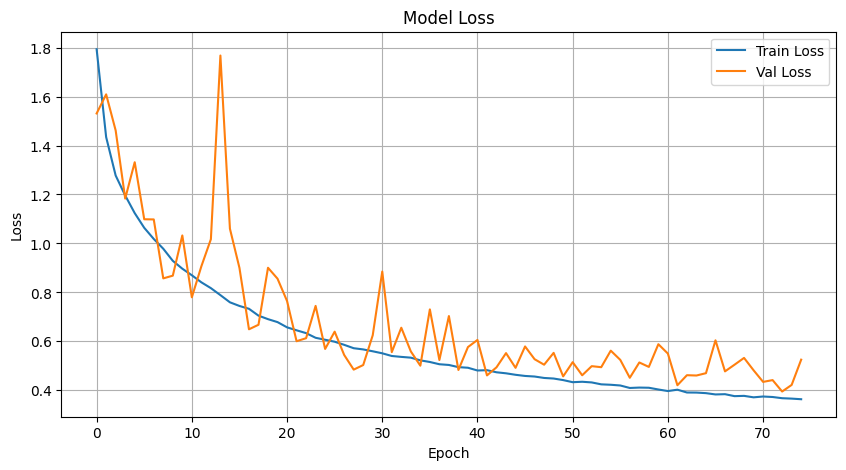

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


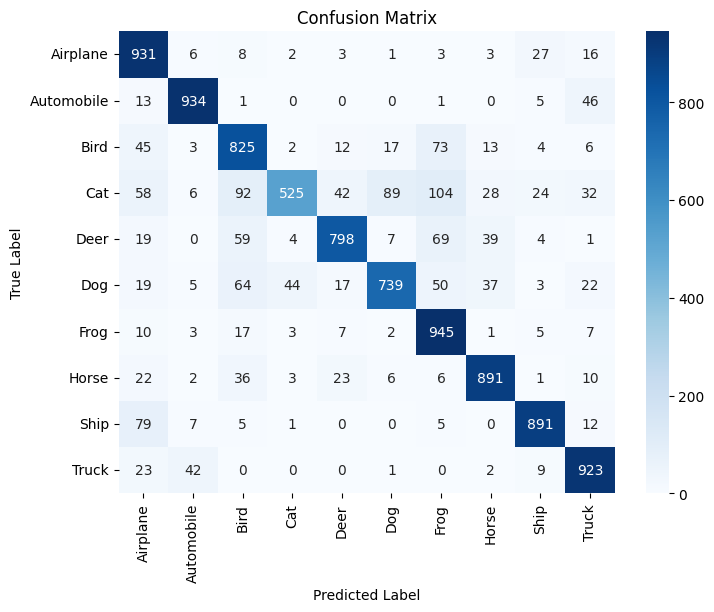

Classification Report:
               precision    recall  f1-score   support

    Airplane       0.76      0.93      0.84      1000
  Automobile       0.93      0.93      0.93      1000
        Bird       0.75      0.82      0.78      1000
         Cat       0.90      0.53      0.66      1000
        Deer       0.88      0.80      0.84      1000
         Dog       0.86      0.74      0.79      1000
        Frog       0.75      0.94      0.84      1000
       Horse       0.88      0.89      0.88      1000
        Ship       0.92      0.89      0.90      1000
       Truck       0.86      0.92      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid(True)
plt.show()

y_pred = model.predict(x_test)
y_pred_classes = tf.argmax(y_pred, axis=1).numpy()

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(
    "Classification Report:\n",
    classification_report(y_test, y_pred_classes, target_names=class_names),
)

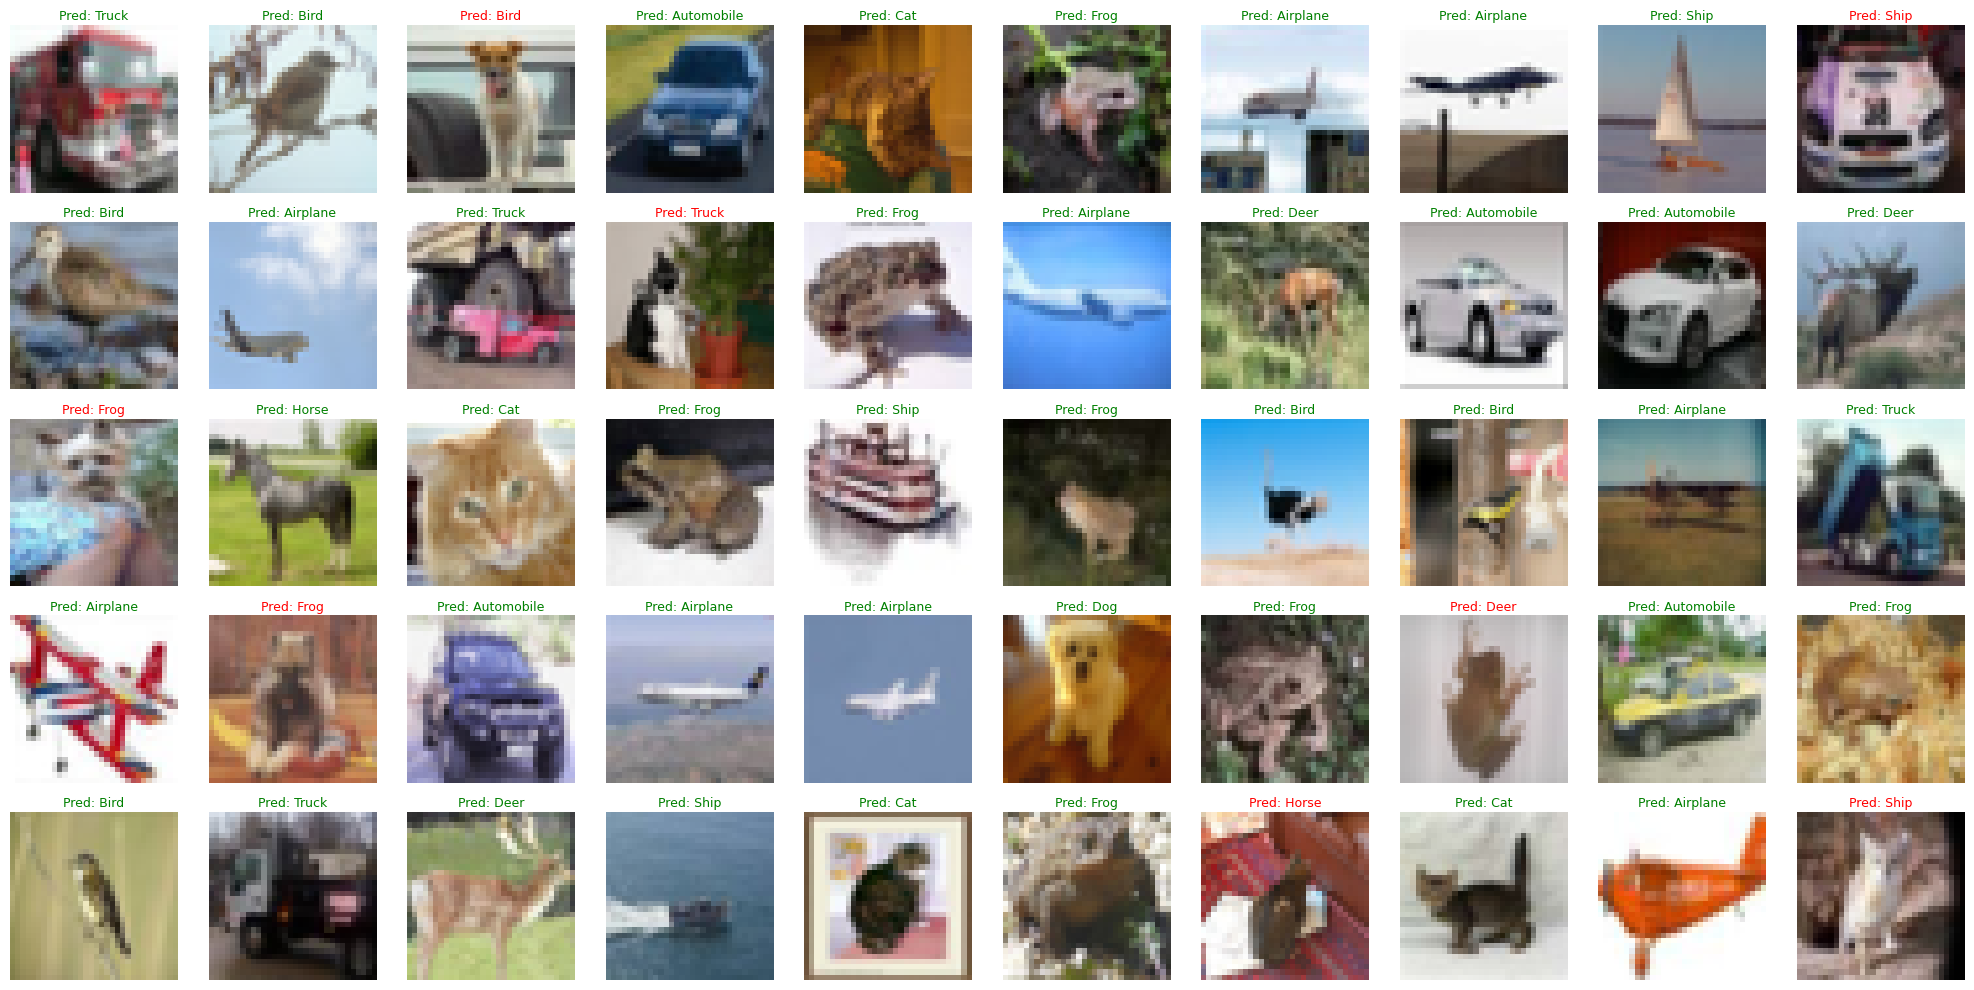

In [ ]:
plt.figure(figsize=(cols * 2, rows * 2))  # bigger images

for i in range(num_samples):
    idx = random.randint(0, len(x_test) - 1)
    img = x_test[idx]
    label = y_test[idx]

    sample = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(sample, verbose=0)
    predicted_label = tf.argmax(prediction[0]).numpy()

    # Plot
    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(img)
    ax.axis("off")

    # Label below image
    pred_text = f"Pred: {class_names[predicted_label]}"
    actual_text = f"Actual: {class_names[label]}"

    # Color predictions: green if correct, red if wrong
    color = "green" if predicted_label == label else "red"

    ax.set_title(pred_text, fontsize=9, color=color, pad=4)
    ax.set_xlabel(actual_text, fontsize=8, color="blue", labelpad=2)

plt.tight_layout()
plt.show()